## Ejercicio 1 — Superficie del riesgo logístico

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import ipykernel
import sys, os

sys.path.append(os.path.abspath(".."))

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("ipykernel:", ipykernel.__version__)
print("Path:", os.path.abspath(".."))

numpy: 2.5.3
scipy: 1.18.1
matplotlib: 3.11.2
ipykernel: 7.3.0
Path: c:\Users\laura\OneDrive\Desktop\Machine Learning\Taller_regresion_logistica_26


In [ ]:
from src import modelo

x = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

print("sigmoide(0) =", modelo.sigmoide(0))
print("p_theta(x)  =", modelo.probabilidad(x, (0, 0)))
print("RS(0, 0)    =", modelo.superficie_riesgo((0, 0), x, y))
print("RS(0, 1)    =", modelo.superficie_riesgo((0, 1), x, y))

sigmoide(0) = 0.5
p_theta(x)  = [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
RS(0, 0)    = 0.6931471805599453
RS(0, 1)    = 0.380500789112006


In [4]:
#EJERCICIO 1, INCISO A 
theta0_vals = np.linspace(-4, 4, 100)
theta1_vals = np.linspace(-1, 6, 100)

Theta0, Theta1 = np.meshgrid(theta0_vals, theta1_vals)

print("Forma de Theta0:", Theta0.shape)
print("Forma de Theta1:", Theta1.shape)

Forma de Theta0: (100, 100)
Forma de Theta1: (100, 100)


In [8]:

#Evaluar RS en la malla
RS_v = np.zeros_like(Theta0)

for i in range(Theta0.shape[0]):
    for j in range(Theta0.shape[1]):
        theta0 = Theta0[i, j]
        theta1 = Theta1[i, j]
        RS_vals[i, j] = modelo.superficie_riesgo((theta0, theta1), x, y)

print("Forma de RS_v:", RS_vals.shape)
print("RS mínimo:", RS_vals.min())
print("RS máximo:", RS_vals.max())

Forma de RS_v: (100, 100)
RS mínimo: 0.2785055048606153
RS máximo: 2.7585136294273007


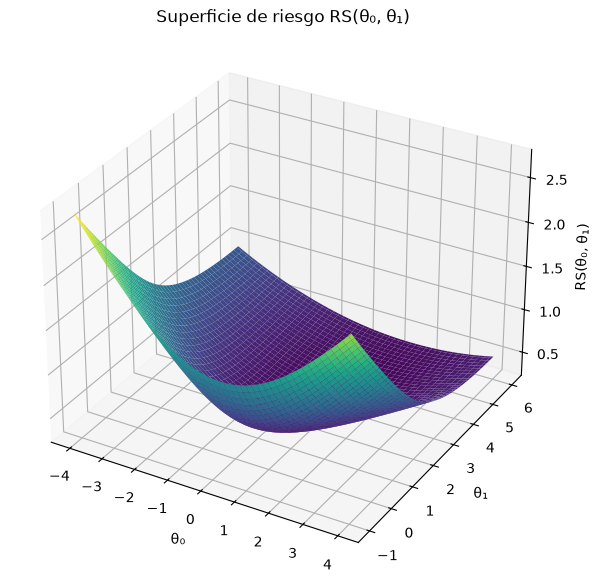

In [14]:
#EJERCICIO 1, INCISO B
#SUPERFICIE 3D
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Theta0, Theta1, RS_vals, cmap="viridis", edgecolor="none")

ax.set_xlabel("θ₀")
ax.set_ylabel("θ₁")
ax.set_zlabel("RS(θ₀, θ₁)")
ax.set_title("Superficie de riesgo RS(θ₀, θ₁)")

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "superficie__3D.png"), dpi=150)
plt.show()

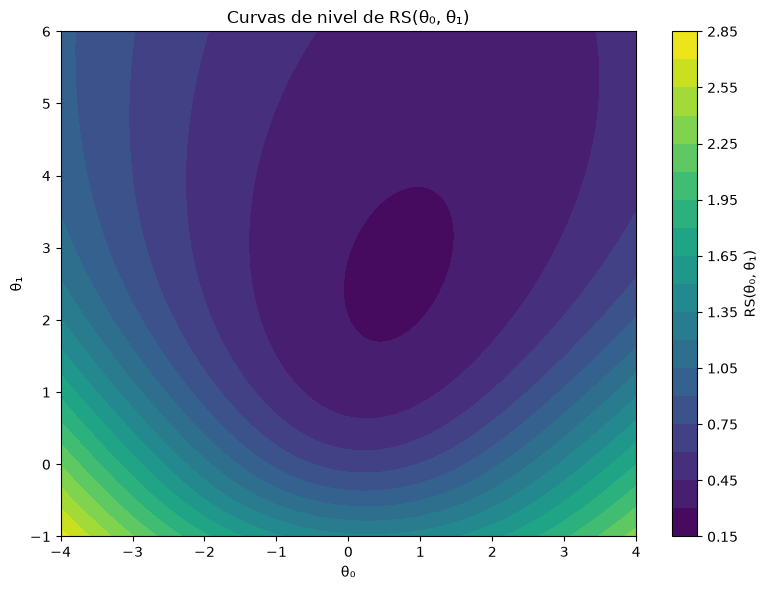

In [16]:
#CURVAS DE NIVEL
plt.figure(figsize=(8, 6))

cp = plt.contourf(Theta0, Theta1, RS_vals, levels=20, cmap="viridis")
plt.colorbar(cp, label="RS(θ₀, θ₁)")

plt.xlabel("θ₀")
plt.ylabel("θ₁")
plt.title("Curvas de nivel de RS(θ₀, θ₁)")

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "superficie_curvas.png"), dpi=150)
plt.show()

In [61]:
#EJERCICIO 1, INCISO C
res = optimizacion.ajustar_modelo(x, y)

theta_opt = res["theta"]
RS_opt = res["RS"]

print("θ* (óptimo) =", theta_opt)
print("RS(θ*)     =", RS_opt)

θ* (óptimo) = [0.65000893 2.5844874 ]
RS(θ*)     = 0.2784542389231837


In [24]:
theta_vec1 = theta_opt + np.array([0.1, 0.0])
theta_vec2 = theta_opt + np.array([0.0, 0.1])

RS_vec1 = modelo.superficie_riesgo(theta_vec1, x, y)
RS_vec2 = modelo.superficie_riesgo(theta_vec2, x, y)
# Definimos las variables que usaremos en el inciso (d)
theta_opt = resultado.x
RS_opt = resultado.fun


print("RS_opt    =", RS_opt)

print("RS(θ*+(0.1,0))=", RS_vec1)
print("RS(θ*+(0,0.1))=", RS_vec2)
print()
print("RS(θ*) < RS(θ*+(0.1,0)) :", RS_opt < RS_vec1)
print("RS(θ*) < RS(θ*+(0,0.1)) :", RS_opt < RS_vec2)

RS_opt    = 0.2784542389231837
RS(θ*+(0.1,0))= 0.2788813438435646
RS(θ*+(0,0.1))= 0.27866459158721596

RS(θ*) < RS(θ*+(0.1,0)) : True
RS(θ*) < RS(θ*+(0,0.1)) : True


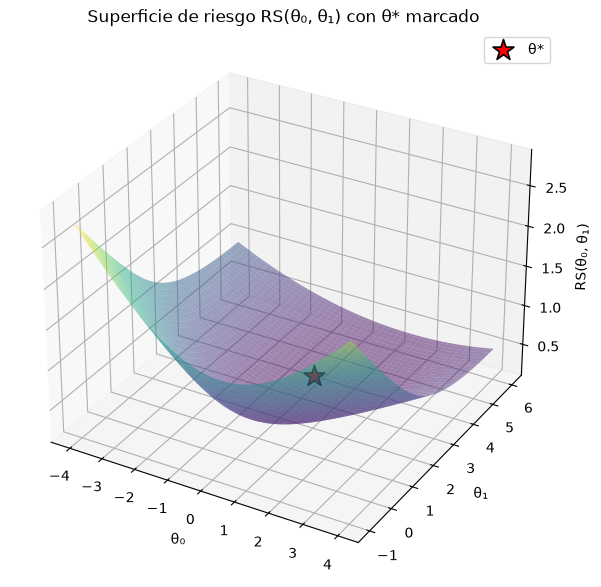

In [ ]:
#EJERCICIO 1, INCISO D, SUPERFICIE 3D CON θ*
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Theta0, Theta1, RS_vals,
                cmap="viridis", edgecolor="none", alpha=0.5)

#Estrela roja para marcar θ*
ax.scatter(theta_opt[0], theta_opt[1], RS_opt + 0.3,
           color="red", s=250, marker="*",
           edgecolor="black", linewidth=1.2,
           label="θ*", depthshade=False)

ax.set_xlabel("θ₀")
ax.set_ylabel("θ₁")
ax.set_zlabel("RS(θ₀, θ₁)")
ax.set_title("Superficie de riesgo RS(θ₀, θ₁) con θ* marcado")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "3D_theta_opt.png"), dpi=150)
plt.show()


Para que la estrella que marca el θ* se pudiera ver bien, le bajé un poco 
la opacidad a la superficie. Si la dejaba completamente sólida, la estrella 
quedaba tapada por la superficie y no se distinguía.

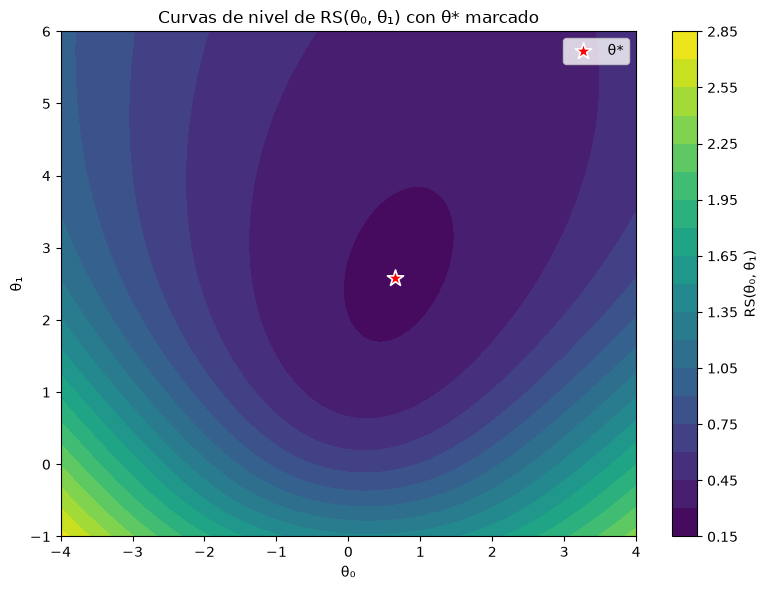

In [30]:
#EJERCICIO 1, INCISO D, CURVAS DE NIVEL CON θ*
plt.figure(figsize=(8, 6))

# Curvas de nivel (igual que en el (b))
cp = plt.contourf(Theta0, Theta1, RS_vals, levels=20, cmap="viridis")
plt.colorbar(cp, label="RS(θ₀, θ₁)")

# Estrella roja en el mínimo θ*
plt.scatter(theta_opt[0], theta_opt[1],
            color="red", s=150, marker="*",
            edgecolor="white", linewidth=1.2,
            label="θ*", zorder=10)

plt.xlabel("θ₀")
plt.ylabel("θ₁")
plt.title("Curvas de nivel de RS(θ₀, θ₁) con θ* marcado")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "curvas_nivel_theta_opt.png"), dpi=150)
plt.show()

## Ejercicio 2 — Datos separables y no separables

In [63]:
#EJERCICIO 2, INCISO A

y_A = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])
y_B = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

#AJUSTE MODELO PARA EL CONJUNTO A
res_A = optimizacion.ajustar_modelo(x, y_A)
theta_A = res_A["theta"]
RS_A = res_A["RS"]

#AJUSTE MODELO PARA EL CONJUNTO B
res_B = optimizacion.ajustar_modelo(x, y_B)
theta_B = res_B["theta"]
RS_B = res_B["RS"]

#REPORTE
print("Conjunto A (separable):")
print("  θ* =", theta_A)
print("  RS(θ*) =", RS_A)
print()
print("Conjunto B (no separable):")
print("  θ* =", theta_B)
print("  RS(θ*) =", RS_B)

Conjunto A (separable):
  θ* = [ 9.41635756 42.00452063]
  RS(θ*) = 1.0074975641291329e-05

Conjunto B (no separable):
  θ* = [0.65000893 2.5844874 ]
  RS(θ*) = 0.2784542389231837


In [ ]:
#EJERCICIO 2, INCISO B

#SE CALCULA LA NORMAS EUCLIDEANAS DE CADA θ
norma_A = np.linalg.norm(theta_A)
norma_B = np.linalg.norm(theta_B)

#Tabla
print(f"{'conjunto':<10} {'‖θ‖₂':<15} {'RS(θ)':<15}")
print(f"{'A':<10} {norma_A:<15.6f} {RS_A:<15.6f}")
print(f"{'B':<10} {norma_B:<15.6f} {RS_B:<15.6f}")

conjunto   ‖θ‖₂            RS(θ)          
A          43.047039       0.000010       
B          2.664974        0.278454       


Se puede ver que en el conjunto A la norma de θ es mucho más grande que en el B. 
Esto tiene sentido porque A es separable, entonces el modelo necesita valores 
grandes de θ para poder separar bien los datos. En cambio, B no es separable, 
así que el modelo llega a valores más pequeños y el riesgo no baja hasta casi cero.

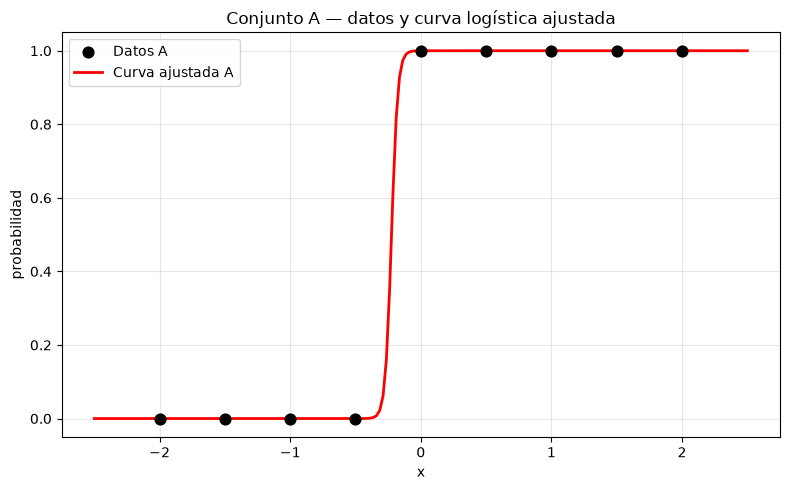

In [ ]:
#EJERCICIO 2, INCISO C, GRAFICA DEL CONJUNTO A 

x_l = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)

#Curva ajustada con θ_A
p_A = modelo.probabilidad(x_l, theta_A)

plt.figure(figsize=(8, 5))

plt.scatter(x, y_A, color="black", s=60, label="Datos A", zorder=3)

#Curva ajustada
plt.plot(x_l, p_A, color="red", linewidth=2, label="Curva ajustada A")

plt.xlabel("x")
plt.ylabel("probabilidad")
plt.title("Conjunto A — datos y curva logística ajustada")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "conjunto_A.png"), dpi=150)
plt.show()

En el conjunto A la curva se ve como un escalón: sube muy rápido. 
Esto es porque los ceros y los unos están bien separados, entonces 
el modelo logra dividirlos casi perfectamente.

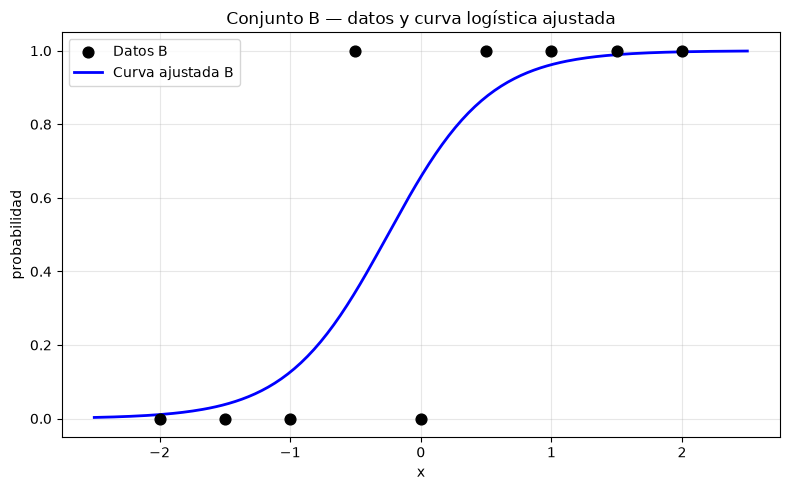

In [39]:
#EJERCICIO 2, INCISO C, GRAFICA DEL CONJUNTO B

x_l = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)
p_B = modelo.probabilidad(x_l, theta_B)

plt.figure(figsize=(8, 5))

# Datos reales
plt.scatter(x, y_B, color="black", s=60, label="Datos B", zorder=3)

# Curva ajustada
plt.plot(x_l, p_B, color="blue", linewidth=2, label="Curva ajustada B")

plt.xlabel("x")
plt.ylabel("probabilidad")
plt.title("Conjunto B — datos y curva logística ajustada")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "conjunto_B.png"), dpi=150)
plt.show()

En el conjunto B la curva sube más despacio y no tiene ese salto. 
Esto es porque hay un dato en el medio que no deja separar bien 
los ceros de los unos, y por eso el modelo no puede ajustar tan bien.

In [65]:
#EJERCICIO 2, INCISO D

#AJUSTE CON maxiter=10
res_10 = optimizacion.ajustar_modelo(x, y_A, maxiter=10)
theta_10 = res_10["theta"]
RS_10 = res_10["RS"]
norma_10 = np.linalg.norm(theta_10)

#AJUSTE CON maxiter=100
res_100 = optimizacion.ajustar_modelo(x, y_A, maxiter=100)
theta_100 = res_100["theta"]
RS_100 = res_100["RS"]
norma_100 = np.linalg.norm(theta_100)

#TABLA
print(f"{'maxiter':<10} {'‖θ‖₂':<18} {'RS(θ)':<18}")
print("-" * 46)
print(f"{10:<10} {norma_10:<18.6f} {RS_10:<18.6f}")
print(f"{100:<10} {norma_100:<18.6f} {RS_100:<18.6f}")

maxiter    ‖θ‖₂               RS(θ)             
----------------------------------------------
10         16.027011          0.005126          
100        43.047039          0.000010          


Al comparar los dos ajustes, se ve que cuando se hacen más iteraciones 
la norma de θ aumenta (pasa de 16 a 43) y el riesgo disminuye (pasa de 
0.005 a casi 0). Esto pasa porque el conjunto A es separable: el modelo 
sigue "empujando" θ para separar mejor los datos, pero nunca termina 
de converger del todo.

Por eso, la afirmación compatible con los resultados es la segunda: 
la norma aumenta mientras el riesgo disminuye hacia cero.

## Ejercicio 3 — Recuperación de parámetros 

In [68]:
#EJERCICIO 3, INCISO A
from src import simulacion
rng = np.random.default_rng(2026)
theta_verdadero = np.array([-1.0, 2.0])
tamanos = [50, 200, 1000]
datos = {}

for n in tamanos:
    X_n, Y_n = simulacion.generar_datos(n, theta_verdadero, rng)
    datos[n] = {"X": X_n, "Y": Y_n}

for n in tamanos:
    print(f"n = {n}:")
    print("  primeros 5 X:", datos[n]["X"][:5])
    print("  primeros 5 Y:", datos[n]["Y"][:5])
    print("  proporción de 1s:", datos[n]["Y"].mean())
    print()

n = 50:
  primeros 5 X: [-1.28426075  0.55965266 -0.1309264  -0.51799789 -0.58033066]
  primeros 5 Y: [0 1 0 0 0]
  proporción de 1s: 0.32

n = 200:
  primeros 5 X: [ 1.25697225 -1.46095419  0.4620331  -0.3886661   1.06414537]
  primeros 5 Y: [1 0 0 0 1]
  proporción de 1s: 0.405

n = 1000:
  primeros 5 X: [ 1.4848303  -0.9339975   1.57612268 -0.77565463 -1.77097176]
  primeros 5 Y: [1 0 1 0 0]
  proporción de 1s: 0.392



In [66]:
#EJERCICIO 3, INCISO B

estimaciones = {}

for n in tamanos:
    X_n = datos[n]["X"]
    Y_n = datos[n]["Y"]
    
    res_n = optimizacion.ajustar_modelo(X_n, Y_n)
    theta_n = res_n["theta"]
    RS_n = res_n["RS"]
    
    estimaciones[n] = {"theta": theta_n, "RS": RS_n}
    
    print(f"n = {n}:")
    print(f"  θ_n     = {theta_n}")
    print(f"  RS(θ_n) = {RS_n}")
    print()

print("Valor verdadero θ* =", theta_verdadero)

n = 50:
  θ_n     = [-1.61377749  2.68444765]
  RS(θ_n) = 0.32244250310862377

n = 200:
  θ_n     = [-0.82299324  2.03820552]
  RS(θ_n) = 0.37675348211019377

n = 1000:
  θ_n     = [-1.06598628  1.84996383]
  RS(θ_n) = 0.40246697790863994

Valor verdadero θ* = [-1.  2.]


Se ve que al aumentar el tamaño de la muestra, el θ estimado se acerca 
más al valor verdadero θ* = (−1, 2). Con n = 50 la estimación está lejos, 
con n = 200 se acerca bastante, y con n = 1000 la estimación ya es 
muy parecida al valor real.

Esto tiene sentido porque con más datos el modelo tiene más información 
para estimar bien los parámetros.

In [44]:
#EJERCICIO 3, INCISO C

print(f"{'n':<8} {'θ₀':<15} {'θ₁':<15} {'e_n':<15}")
print("-" * 55)

for n in tamanos:
    theta_n = estimaciones[n]["theta"]
    error_n = np.linalg.norm(theta_n - theta_verdadero)
    
    print(f"{n:<8} {theta_n[0]:<15.6f} {theta_n[1]:<15.6f} {error_n:<15.6f}")

n        θ₀              θ₁              e_n            
-------------------------------------------------------
50       -1.613777       2.684448        0.919343       
200      -0.822993       2.038206        0.181083       
1000     -1.065986       1.849964        0.163906       


En la tabla se ve que a medida que n crece, el error e_n disminuye. 

In [ ]:
#EJERCICIO 3, INCISO D

#Errores de cada n
errores = {}
for n in tamanos:
    theta_n = estimaciones[n]["theta"]
    errores[n] = np.linalg.norm(theta_n - theta_verdadero)

#1) ¿Cuál n dio el MENOR error?
n_menor = min(errores, key=errores.get)
print(f"El menor error se obtuvo con n = {n_menor}")
print(f"  e_{n_menor} = {errores[n_menor]:.6f}")
print()

#2) ¿Se cumple e_1000 < e_50?
print(f"e_1000 = {errores[1000]:.6f}")
print(f"e_50   = {errores[50]:.6f}")
print(f"¿e_1000 < e_50?  =  {errores[1000] < errores[50]}")

El menor error se obtuvo con n = 1000
  e_1000 = 0.163906

e_1000 = 0.163906
e_50   = 0.919343
¿e_1000 < e_50?  =  True


## Ejercicio 4 — Interpretación de los parámetros



### Inciso (a) — Demostración

Queremos probar que:

$$p_\theta(x) = \tfrac{1}{2} \iff x = -\frac{\theta_0}{\theta_1}$$

Definición:

$$p_\theta(x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x)}}$$

Igualamos a $1/2$:

$$\frac{1}{1 + e^{-(\theta_0 + \theta_1 x)}} = \frac{1}{2}$$

Multiplicamos ambos lados por $1 + e^{-(\theta_0 + \theta_1 x)}$:

$$1 = \frac{1}{2}\left(1 + e^{-(\theta_0 + \theta_1 x)}\right)$$

Multiplicamos por 2:

$$2 = 1 + e^{-(\theta_0 + \theta_1 x)}$$

Restamos 1:

$$1 = e^{-(\theta_0 + \theta_1 x)}$$

Aplicamos logaritmo natural:

$$0 = -(\theta_0 + \theta_1 x)$$

Multiplicamos por -1:

$$\theta_0 + \theta_1 x = 0$$

Despejamos $x$, asumiendo $\theta_1 \neq 0$:

$$\boxed{x = -\frac{\theta_0}{\theta_1}}$$

Por lo tanto, $p_\theta(x) = \tfrac{1}{2} \iff x = -\theta_0/\theta_1$. $\blacksquare$

θ₀=-2: x* = 2.0, p(x*) = 0.500000
θ₀=0: x* = 0.0, p(x*) = 0.500000
θ₀=2: x* = -2.0, p(x*) = 0.500000


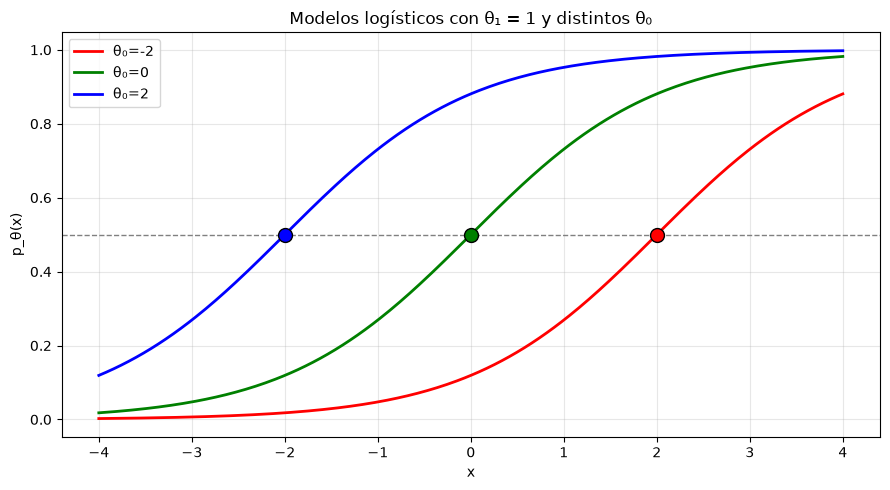

In [ ]:
#EJERCICIO 4, INCISO B

theta1_fijo = 1.0
theta0_lista = [-2, 0, 2]
colores = ["red", "green", "blue"]

x_l= np.linspace(-4, 4, 300)

plt.figure(figsize=(9, 5))

for theta0, color in zip(theta0_lista, colores):
    theta = (theta0, theta1_fijo)
    
    # Curva
    p = modelo.probabilidad(x_l, theta)
    plt.plot(x_l, p, color=color, linewidth=2,
             label=f"θ₀={theta0}")
    
    #Frontera x* = -theta0 / theta1
    x_s = -theta0 / theta1_fijo
    p_s = modelo.probabilidad(np.array([x_s]), theta)[0]
    
    plt.scatter(x_s, p_s, color=color, s=100, zorder=5, edgecolor="black")
    
    # Comprobación
    print(f"θ₀={theta0}: x* = {x_s}, p(x*) = {p_s:.6f}")

# Línea de referencia en 0.5
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)

plt.xlabel("x")
plt.ylabel("p_θ(x)")
plt.title("Modelos logísticos con θ₁ = 1 y distintos θ₀")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "ej4_curvas_theta0.png"), dpi=150)
plt.show()

Lo que veo en la gráfica es que cambiar θ₀ solo mueve la curva hacia 
un lado u otro, pero no cambia su forma. Cuando θ₀ = −2 la curva queda 
corrida hacia la derecha, cuando θ₀ = 0 queda en el centro y cuando 
θ₀ = 2 se corre hacia la izquierda.

También comprobé que la frontera x* = −θ₀/θ₁ cae en 2, 0 y −2, y en 
los tres casos la probabilidad en ese punto da exactamente 0.5. 
Eso tiene sentido porque es justo el punto donde el modelo queda 
en la mitad

θ₁=1: p(1)=0.731059, p(-1)=0.268941, p(1)-p(-1)=0.462117
θ₁=2: p(1)=0.880797, p(-1)=0.119203, p(1)-p(-1)=0.761594
θ₁=5: p(1)=0.993307, p(-1)=0.006693, p(1)-p(-1)=0.986614


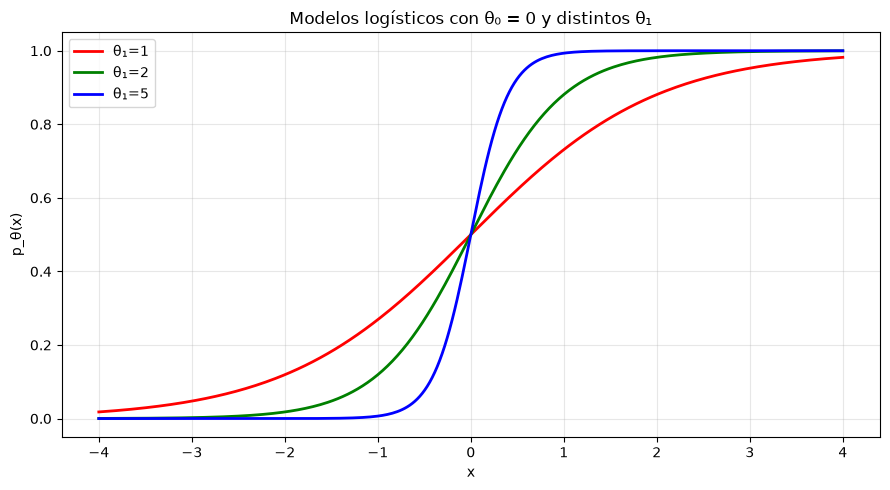

In [50]:
#EJERCICIO 4, INCISO C
theta0_fijo = 0.0
theta1_lista = [1, 2, 5]
colores = ["red", "green", "blue"]

x_l= np.linspace(-4, 4, 300)

plt.figure(figsize=(9, 5))

for theta1, color in zip(theta1_lista, colores):
    theta = (theta0_fijo, theta1)
    
    # Curva
    p = modelo.probabilidad(x_l, theta)
    plt.plot(x_l, p, color=color, linewidth=2, label=f"θ₁={theta1}")
    
    # p(1) - p(-1)
    p_1 = modelo.probabilidad(np.array([1.0]), theta)[0]
    p_menos1 = modelo.probabilidad(np.array([-1.0]), theta)[0]
    diferencia = p_1 - p_menos1
    
    print(f"θ₁={theta1}: p(1)={p_1:.6f}, p(-1)={p_menos1:.6f}, "
          f"p(1)-p(-1)={diferencia:.6f}")

plt.xlabel("x")
plt.ylabel("p_θ(x)")
plt.title("Modelos logísticos con θ₀ = 0 y distintos θ₁")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("..", "resultados", "ej4_curvas_theta1.png"), dpi=150)
plt.show()

En esta gráfica se ve que al subir el valor de θ₁ la curva se hace 
más empinada. Con θ₁ = 1 sube despacio, con θ₁ = 2 sube más rápido 
y con θ₁ = 5 casi que salta de 0 a 1 de una vez.

Entonces el modelo con θ₁ = 5 es el que tiene la transición más abrupta, 
porque entre x = −1 y x = 1 la probabilidad cambia casi de 0 a 1.

In [69]:
#EJERCICIO 5, INCISO A
rng5 = np.random.default_rng(2026)
n5 = 5000

X5, Y5 = simulacion.generar_datos(n5, theta_verdadero, rng5)
p5 = modelo.probabilidad(X5, theta_verdadero)

# L(theta*)
L_valor = np.prod(p5**Y5 * (1 - p5)**(1 - Y5))

# logL(theta*)
logL_valor = np.sum(Y5 * np.log(p5) + (1 - Y5) * np.log(1 - p5))

print("n =", n5)
print("L(θ*)    =", L_valor)
print("logL(θ*) =", logL_valor)

n = 5000
L(θ*)    = 0.0
logL(θ*) = -1954.920071716625


In [54]:
#EJERCICIO 5, INCISO B

print("L(θ*)    =", L_valor)
print("logL(θ*) =", logL_valor)
print()

# ¿logL es un número finito?
print("¿logL(θ*) es finito?  =", np.isfinite(logL_valor))

L(θ*)    = 0.0
logL(θ*) = -1954.920071716625

¿logL(θ*) es finito?  = True


In [57]:
#EJERCICIO 5, INCISO C

# Calculamos RS(theta*) con los datos del Ejercicio 5
RS_s = modelo.superficie_riesgo(theta_verdadero, X5, Y5)

# Calculamos delta
delta = -logL_valor - n5 * RS_s

print("RS(θ*)        =", RS_s)
print("-logL(θ*)     =", -logL_valor)
print("n * RS(θ*)    =", n5 * RS_s)
print()
print("delta = -logL(θ*) - n*RS(θ*) =", delta)
print()
print("¿delta < 1e-8?  =", abs(delta) < 1e-8)

RS(θ*)        = 0.39098401434332497
-logL(θ*)     = 1954.920071716625
n * RS(θ*)    = 1954.9200717166248

delta = -logL(θ*) - n*RS(θ*) = 2.2737367544323206e-13

¿delta < 1e-8?  = True
